# Battery Health — Across-Cycle Sequence Forecasting (DL vs RF)

Notebook 04 of the DL phase. Trains **LSTM**, **GRU**, and **TCN** on the *macro clock* —
one timestep = one full cycle, sequence = the degradation trajectory — and rematches the
Practical RF baseline with the same LOBO protocol.

| | This notebook |
|---|---|
| Phase | **Practical** (13 batteries, `r_proxy` only) |
| Targets | `rul_frac` (lead) · `energy_retention` (secondary) |
| Architectures | LSTM · GRU · TCN |
| Validation | Leave-One-Battery-Out (same folds as notebook 03) |
| Expected outcome | DL roughly **ties or loses** to RF — 13 trajectories is data-starved |

The tie/loss is the intended finding: it motivates moving to the *within-cycle* clock in
notebooks 05–06, where DL has ~800 samples and a signal (charge-curve shape) the scalar
baselines never saw.

## 1. Imports & setup

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
import torch

from src.sequence import (
    make_sequences, LSTMReg, GRUReg, TCNReg, train_model, predict_model
)

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="tab10")

PROCESSED = Path("../data/processed")
RESULTS   = Path("../results")
MODELS    = Path("../models")
RESULTS.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)

torch.manual_seed(42)
np.random.seed(42)

device = (
    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cuda") if torch.cuda.is_available()
    else torch.device("cpu")
)
print(f"Device: {device}")

Device: mps


## 2. Load & merge

Same merge as notebook 03 Practical phase: intersect columns, concat.

In [2]:
ctrl = pd.read_csv(PROCESSED / "controlled.csv")
rw   = pd.read_csv(PROCESSED / "randomized.csv")

shared_cols = [c for c in ctrl.columns if c in rw.columns]
merged = pd.concat([ctrl[shared_cols], rw[shared_cols]], ignore_index=True)

print(f"Merged: {len(merged)} rows, {merged.battery_id.nunique()} batteries")
print(f"Batteries: {sorted(merged.battery_id.unique())}")
print()
print("Cycles per battery:")
print(merged.groupby("battery_id")["cycle_index"].max().sort_values().to_string())

Merged: 801 rows, 13 batteries
Batteries: ['B0005', 'B0006', 'B0007', 'B0018', 'RW1', 'RW13', 'RW14', 'RW15', 'RW16', 'RW17', 'RW19', 'RW20', 'RW9']

Cycles per battery:
battery_id
RW16      10
RW13      12
RW14      12
RW15      13
RW19      15
RW17      16
RW20      16
RW1       23
RW9       39
B0018    131
B0005    167
B0006    167
B0007    167


## 3. Feature channels

Base per-cycle features only — **no pre-rolled 5/10/15/20 stats**. The sequence model
re-derives temporal statistics from the ordered window itself; including pre-rolled columns
would double-count the rolling signal.

`cycle_norm` is excluded (it's `cycle_index / max_cycle` — encodes the `rul_frac` answer
directly, per notebook 03's leakage guard). Efficiency excludes capacity columns
(same guard as notebook 03: `capacity_ahr`, `capacity_retention`, `cap_delta_from_baseline`
correlate directly with `energy_retention`).

In [3]:
CHANNELS_LIFESPAN = [
    "r_proxy", "voltage_mean", "temp_mean", "temp_max",
    "duration_s", "capacity_ahr", "capacity_retention", "cap_delta_from_baseline",
]
CHANNELS_EFFICIENCY = [
    "r_proxy", "voltage_mean", "temp_mean", "temp_max", "duration_s",
]

LEAK = {"cycle_norm", "rul_frac", "rul_cycles", "rul_censored",
        "energy_retention", "energy_wh", "eol_index",
        "battery_id", "cycle_index", "split"}
assert not LEAK & set(CHANNELS_LIFESPAN),   "Leakage in lifespan channels!"
assert not LEAK & set(CHANNELS_EFFICIENCY), "Leakage in efficiency channels!"

print(f"Lifespan channels   ({len(CHANNELS_LIFESPAN)} features): {CHANNELS_LIFESPAN}")
print(f"Efficiency channels ({len(CHANNELS_EFFICIENCY)} features): {CHANNELS_EFFICIENCY}")
print("Leakage guards: OK")

Lifespan channels   (8 features): ['r_proxy', 'voltage_mean', 'temp_mean', 'temp_max', 'duration_s', 'capacity_ahr', 'capacity_retention', 'cap_delta_from_baseline']
Efficiency channels (5 features): ['r_proxy', 'voltage_mean', 'temp_mean', 'temp_max', 'duration_s']
Leakage guards: OK


## 4. Windowing sanity check

`make_sequences` must emit exactly one sample per row (one prediction per cycle per battery).
Pad rate shows how much of the tensor is zero-filled (expected for short RW batteries).

In [4]:
_X, _y, _mask, _groups, _cidx = make_sequences(merged, CHANNELS_LIFESPAN, "rul_frac", L=10)
assert len(_X) == len(merged), f"Expected {len(merged)} samples, got {len(_X)}"
print(f"make_sequences OK")
print(f"  X shape : {_X.shape}  (n_samples, L, C)")
print(f"  y shape : {_y.shape}")
print(f"  mask    : {_mask.shape}  (True=valid, False=pad)")
print(f"  Pad rate: {(~_mask).mean():.1%} of timesteps are zero-padded")
print(f"  y range : [{_y.min():.3f}, {_y.max():.3f}]")
del _X, _y, _mask, _groups, _cidx

make_sequences OK
  X shape : (801, 10, 8)  (n_samples, L, C)
  y shape : (801,)
  mask    : (801, 10)  (True=valid, False=pad)
  Pad rate: 7.3% of timesteps are zero-padded
  y range : [0.000, 1.000]


## 5. Architecture map

In [5]:
ARCH_MAP = {"LSTM": LSTMReg, "GRU": GRUReg, "TCN": TCNReg}

# Quick parameter count sanity check
for arch, Cls in ARCH_MAP.items():
    m = Cls(n_features=len(CHANNELS_LIFESPAN))
    n_params = sum(p.numel() for p in m.parameters())
    print(f"{arch:5s}  {n_params:,} params")

LSTM   5,409 params
GRU    4,065 params
TCN    4,225 params


## 6. Tier-1 sweep — lookback & epoch budget

Fixed train/val split (same batteries as notebook 03's `split` column: train→train, test→val).
Sweep `L ∈ {5, 10, 15, 20}` × 3 architectures on `rul_frac`. Best `L` per architecture
is used in Tier-2 LOBO; `best_epoch` from early stopping sets the training budget.

In [6]:
LOOKBACKS      = [5, 10, 15, 20]
TIER1_EPOCHS   = 300
TIER1_PATIENCE = 30

train_bids_t1 = merged.loc[merged["split"] == "train", "battery_id"].unique()
val_bids_t1   = merged.loc[merged["split"] == "test",  "battery_id"].unique()
train_df_t1   = merged[merged["battery_id"].isin(train_bids_t1)].copy()
val_df_t1     = merged[merged["battery_id"].isin(val_bids_t1)].copy()

print(f"Tier-1 train batteries ({len(train_bids_t1)}): {sorted(train_bids_t1)}")
print(f"Tier-1 val   batteries ({len(val_bids_t1)}):  {sorted(val_bids_t1)}")

Tier-1 train batteries (9): ['B0005', 'B0006', 'B0018', 'RW1', 'RW13', 'RW14', 'RW16', 'RW17', 'RW9']
Tier-1 val   batteries (4):  ['B0007', 'RW15', 'RW19', 'RW20']


In [7]:
def run_tier1_sweep(channels, target, lookbacks, arch_map, epochs, patience):
    scaler = StandardScaler().fit(train_df_t1[channels])
    tr = train_df_t1.copy()
    va = val_df_t1.copy()
    tr[channels] = scaler.transform(tr[channels])
    va[channels] = scaler.transform(va[channels])

    rows = []
    for L in lookbacks:
        X_tr, y_tr, m_tr, _, _ = make_sequences(tr, channels, target, L)
        X_va, y_va, m_va, _, _ = make_sequences(va, channels, target, L)
        for arch_name, ArchClass in arch_map.items():
            torch.manual_seed(42)
            model = ArchClass(n_features=len(channels)).to(device)
            _, tr_curve, va_curve, best_ep = train_model(
                model, X_tr, m_tr, y_tr, X_va, m_va, y_va,
                device, epochs=epochs, patience=patience,
            )
            y_pred   = predict_model(model, X_va, m_va, device)
            val_mae  = float(mean_absolute_error(y_va, y_pred))
            rows.append({
                "L": L, "arch": arch_name,
                "val_mae": val_mae, "best_epoch": best_ep,
                "train_curve": tr_curve, "val_curve": va_curve,
            })
            print(f"  L={L:2d}  {arch_name:5s}  val_mae={val_mae:.4f}  best_ep={best_ep}")
    return pd.DataFrame(rows)

print("=== Tier-1 sweep — rul_frac ===")
tier1_life = run_tier1_sweep(
    CHANNELS_LIFESPAN, "rul_frac", LOOKBACKS, ARCH_MAP,
    TIER1_EPOCHS, TIER1_PATIENCE
)

=== Tier-1 sweep — rul_frac ===
  L= 5  LSTM   val_mae=0.0477  best_ep=124
  L= 5  GRU    val_mae=0.0425  best_ep=224
  L= 5  TCN    val_mae=0.0309  best_ep=16
  L=10  LSTM   val_mae=0.0549  best_ep=175
  L=10  GRU    val_mae=0.0700  best_ep=77
  L=10  TCN    val_mae=0.0353  best_ep=19
  L=15  LSTM   val_mae=0.0773  best_ep=103
  L=15  GRU    val_mae=0.0820  best_ep=89
  L=15  TCN    val_mae=0.0372  best_ep=13
  L=20  LSTM   val_mae=0.0979  best_ep=103
  L=20  GRU    val_mae=0.1081  best_ep=89
  L=20  TCN    val_mae=0.0344  best_ep=11


In [8]:
# Best L and epoch budget per architecture
best_L_per_arch  = {}
best_ep_per_arch = {}

print("Best configuration per architecture (rul_frac tier-1 val):")
for arch in ARCH_MAP:
    sub = tier1_life[tier1_life["arch"] == arch]
    best_row = sub.loc[sub["val_mae"].idxmin()]
    best_L_per_arch[arch]  = int(best_row["L"])
    best_ep_per_arch[arch] = int(best_row["best_epoch"])
    print(f"  {arch:5s}  L={best_L_per_arch[arch]:2d}  "
          f"epochs={best_ep_per_arch[arch]:3d}  "
          f"val_MAE={best_row['val_mae']:.4f}")

Best configuration per architecture (rul_frac tier-1 val):
  LSTM   L= 5  epochs=124  val_MAE=0.0477
  GRU    L= 5  epochs=224  val_MAE=0.0425
  TCN    L= 5  epochs= 16  val_MAE=0.0309


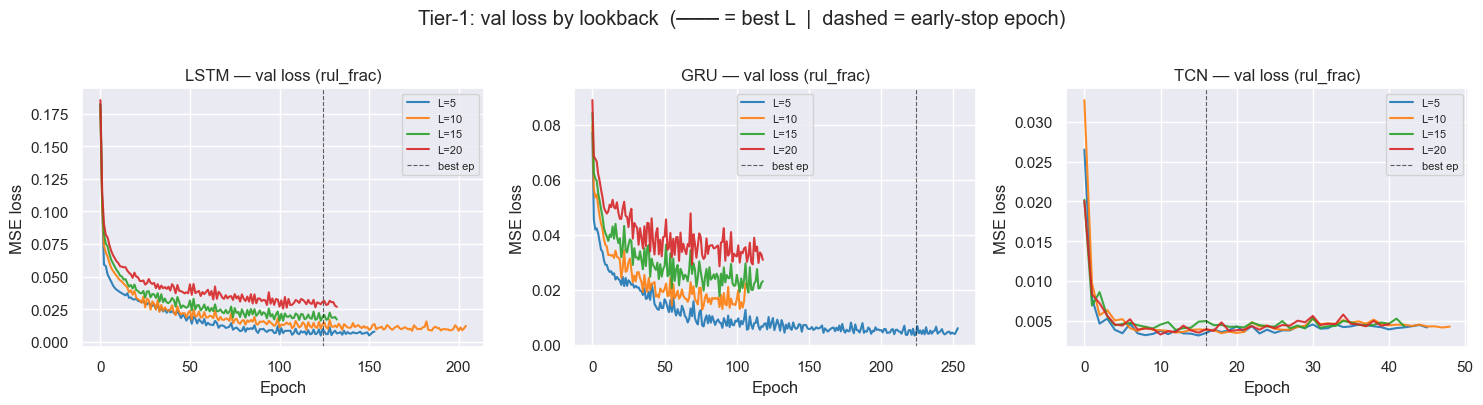

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
colors = {5: "#1f77b4", 10: "#ff7f0e", 15: "#2ca02c", 20: "#d62728"}

for ax, arch in zip(axes, ARCH_MAP):
    for _, row in tier1_life[tier1_life["arch"] == arch].iterrows():
        ax.plot(row["val_curve"], color=colors[row["L"]],
                alpha=0.9, label=f"L={row['L']}")
    ax.axvline(best_ep_per_arch[arch], color="k", ls="--", lw=0.8, alpha=0.6, label="best ep")
    ax.set(title=f"{arch} — val loss (rul_frac)", xlabel="Epoch", ylabel="MSE loss")
    ax.legend(fontsize=8)

plt.suptitle("Tier-1: val loss by lookback  (─── = best L  |  dashed = early-stop epoch)",
             y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / "dl_macro_learning_curves.png", dpi=150)
plt.show()

## 7. Tier-2 LOBO — final evaluation

Full Leave-One-Battery-Out over all 13 batteries, using the lookback and epoch budget
selected in Tier-1. For early stopping within each fold, the last-alphabetically training
battery is held out as an inner validation fold; the reported metrics are on the
*outer* held-out battery (never touched during training or early stopping).

Metrics match notebook 03's format exactly for apples-to-apples comparison.

In [12]:
def monotonicity_rate(y_pred: np.ndarray) -> float:
    if len(y_pred) < 2:
        return float("nan")
    return float((np.diff(y_pred) <= 0).mean())


def lobo_cv_seq(df, channels, target, arch_name, L, epochs,
                eol_col=None, patience=30, seed=42) -> dict:
    """
    LOBO cross-validation for sequence models.
    Inner val battery = last alphabetically among training batteries.
    Returns same summary format as lobo_cv in notebook 03.
    Per-fold dicts include y_true_arr / y_pred_arr / cidx_arr for OOF assembly.
    """
    all_bids     = sorted(df["battery_id"].unique())
    fold_results = []

    for held_out in all_bids:
        train_bids = [b for b in all_bids if b != held_out]
        val_bid    = sorted(train_bids)[-1]                   # inner early-stopping fold
        inner_bids = [b for b in train_bids if b != val_bid]

        inner_df = df[df["battery_id"].isin(inner_bids)].copy()
        val_df_  = df[df["battery_id"] == val_bid].copy()
        test_df_ = df[df["battery_id"] == held_out].copy()

        scaler = StandardScaler().fit(inner_df[channels])
        inner_df[channels] = scaler.transform(inner_df[channels])
        val_df_[channels]  = scaler.transform(val_df_[channels])
        test_df_[channels] = scaler.transform(test_df_[channels])

        X_in, y_in, m_in, _, _       = make_sequences(inner_df, channels, target, L)
        X_va, y_va, m_va, _, _       = make_sequences(val_df_,  channels, target, L)
        X_te, y_te, m_te, _, cidx_te = make_sequences(test_df_, channels, target, L)

        torch.manual_seed(seed)
        model = ARCH_MAP[arch_name](n_features=len(channels)).to(device)
        train_model(
            model, X_in, m_in, y_in, X_va, m_va, y_va,
            device, epochs=epochs, patience=patience,
        )

        y_pred    = predict_model(model, X_te, m_te, device)
        # naive: predict mean of ALL training batteries (inner + val), matching notebook 03
        train_mean = np.concatenate([y_in, y_va]).mean()
        naive_mae  = mean_absolute_error(y_te, np.full(len(y_te), train_mean))
        mae        = mean_absolute_error(y_te, y_pred)

        order      = np.argsort(cidx_te)
        y_pred_ord = y_pred[order]

        fold = {
            "battery":      held_out,
            "n_test":       len(y_te),
            "mae":          mae,
            "rmse":         float(np.sqrt(mean_squared_error(y_te, y_pred))),
            "r2":           r2_score(y_te, y_pred),
            "naive_mae":    naive_mae,
            "skill":        float(1 - mae / naive_mae) if naive_mae > 0 else float("nan"),
            "spearman":     float(spearmanr(y_te, y_pred).statistic),
            "monotonicity": monotonicity_rate(y_pred_ord),
            # store arrays for OOF scatter / trajectory plots
            "y_true_arr":   y_te,
            "y_pred_arr":   y_pred,
            "cidx_arr":     cidx_te,
        }
        if eol_col is not None:
            eol = test_df_[eol_col].to_numpy()
            fold["mae_cycles"] = mean_absolute_error(y_te * eol, y_pred * eol)

        fold_results.append(fold)

    summary = {}
    for key in ["mae", "rmse", "r2", "naive_mae", "skill",
                "spearman", "monotonicity", "mae_cycles"]:
        vals = [f[key] for f in fold_results if key in f and not np.isnan(f[key])]
        if vals:
            summary[key]          = float(np.mean(vals))
            summary[f"{key}_std"] = float(np.std(vals))
    summary["per_fold"] = fold_results
    return summary


print("LOBO harness ready.")

LOBO harness ready.


In [13]:
BEST_ARCH = "TCN"
L  = best_L_per_arch[BEST_ARCH]
ep = best_ep_per_arch[BEST_ARCH]

print(f"=== Tier-2 LOBO \u2014 rul_frac  [{BEST_ARCH}, L={L}, epochs={ep}] ===\n")
lobo_life_tcn = lobo_cv_seq(
    merged, CHANNELS_LIFESPAN, "rul_frac", BEST_ARCH,
    L=L, epochs=ep, eol_col="eol_index"
)
res = lobo_life_tcn
print(
    f"  MAE={res['mae']:.4f}\u00b1{res['mae_std']:.4f}  "
    f"RMSE={res['rmse']:.4f}  "
    f"R\u00b2={res['r2']:.3f}\u00b1{res['r2_std']:.3f}  "
    f"\u03c1={res.get('spearman', float('nan')):.3f}  "
    f"mono={res.get('monotonicity', float('nan')):.3f}  "
    f"skill={res.get('skill', float('nan')):.3f}  "
    f"MAE_cyc={res.get('mae_cycles', float('nan')):.1f}"
)

=== Tier-2 LOBO — rul_frac  [TCN, L=5, epochs=16] ===

  MAE=0.0417±0.0214  RMSE=0.0702  R²=0.935±0.078  ρ=0.902  mono=0.847  skill=0.858  MAE_cyc=1.6


In [14]:
print(f"=== Tier-2 LOBO \u2014 energy_retention  [{BEST_ARCH}, L={L}, epochs={ep}] ===\n")
lobo_eff_tcn = lobo_cv_seq(
    merged, CHANNELS_EFFICIENCY, "energy_retention", BEST_ARCH,
    L=L, epochs=ep
)
res = lobo_eff_tcn
print(
    f"  MAE={res['mae']:.4f}\u00b1{res['mae_std']:.4f}  "
    f"RMSE={res['rmse']:.4f}  "
    f"R\u00b2={res['r2']:.3f}\u00b1{res['r2_std']:.3f}  "
    f"\u03c1={res.get('spearman', float('nan')):.3f}  "
    f"mono={res.get('monotonicity', float('nan')):.3f}  "
    f"skill={res.get('skill', float('nan')):.3f}"
)

=== Tier-2 LOBO — energy_retention  [TCN, L=5, epochs=16] ===

  MAE=0.0570±0.0315  RMSE=0.0718  R²=0.592±0.570  ρ=0.896  mono=0.697  skill=0.560


## 8. Results

In [15]:
def fmt(val, std=None, decimals=4):
    if pd.isna(val): return "\u2014"
    s = f"{val:.{decimals}f}"
    if std is not None and not pd.isna(std):
        s += f" \u00b1 {std:.{decimals}f}"
    return s


def res_to_row(res, task_label, has_cyc):
    row = {
        "Phase": "Practical DL", "Task": task_label, "Algorithm": "TCN",
        "MAE \u00b1 std":    fmt(res.get("mae"),         res.get("mae_std")),
        "RMSE \u00b1 std":   fmt(res.get("rmse"),        res.get("rmse_std")),
        "R\u00b2 \u00b1 std": fmt(res.get("r2"),          res.get("r2_std"), decimals=3),
        "Skill":          fmt(res.get("skill"),        decimals=3),
        "Spearman \u03c1": fmt(res.get("spearman"),     decimals=3),
        "Monotonicity":   fmt(res.get("monotonicity"), decimals=3),
    }
    if has_cyc:
        row["MAE (cycles)"] = fmt(res.get("mae_cycles"), res.get("mae_cycles_std"), decimals=1)
    return row


dl_rows = [
    res_to_row(lobo_life_tcn, "Lifespan",   True),
    res_to_row(lobo_eff_tcn,  "Efficiency", False),
]

# Baseline rows from 03_train_summary.md
baseline_rows = [
    {"Phase": "Practical RF", "Task": "Lifespan",   "Algorithm": "RF",
     "MAE \u00b1 std": "0.0317 \u00b1 0.0192", "RMSE \u00b1 std": "0.0537 \u00b1 0.0281",
     "R\u00b2 \u00b1 std": "0.966 \u00b1 0.033",
     "Skill": "0.892", "Spearman \u03c1": "0.920", "Monotonicity": "0.926",
     "MAE (cycles)": "1.5 \u00b1 2.3"},
    {"Phase": "Practical RF", "Task": "Lifespan",   "Algorithm": "GBM",
     "MAE \u00b1 std": "0.0349 \u00b1 0.0225", "RMSE \u00b1 std": "0.0556 \u00b1 0.0325",
     "R\u00b2 \u00b1 std": "0.961 \u00b1 0.038",
     "Skill": "0.881", "Spearman \u03c1": "0.874", "Monotonicity": "0.737",
     "MAE (cycles)": "1.8 \u00b1 2.6"},
    {"Phase": "Practical RF", "Task": "Efficiency", "Algorithm": "RF",
     "MAE \u00b1 std": "0.0323 \u00b1 0.0348", "RMSE \u00b1 std": "0.0373 \u00b1 0.0377",
     "R\u00b2 \u00b1 std": "0.848 \u00b1 0.243",
     "Skill": "0.758", "Spearman \u03c1": "0.987", "Monotonicity": "0.855"},
    {"Phase": "Practical RF", "Task": "Efficiency", "Algorithm": "Ridge",
     "MAE \u00b1 std": "0.0574 \u00b1 0.0295", "RMSE \u00b1 std": "0.0686 \u00b1 0.0292",
     "R\u00b2 \u00b1 std": "0.757 \u00b1 0.209",
     "Skill": "0.632", "Spearman \u03c1": "0.945", "Monotonicity": "0.846"},
]

comparison = pd.DataFrame(dl_rows + baseline_rows).fillna("").set_index(["Phase", "Task", "Algorithm"])
print("=== Lifespan (rul_frac) ===")
display(comparison[comparison.index.get_level_values("Task") == "Lifespan"])
print()
print("=== Efficiency (energy_retention) ===")
display(comparison[comparison.index.get_level_values("Task") == "Efficiency"])

# Save raw numbers
pd.DataFrame([
    {"phase": "practical_dl", "task": "lifespan",   "algorithm": "TCN",
     **{k: lobo_life_tcn.get(k, float("nan"))
        for k in ["mae","mae_std","rmse","rmse_std","r2","r2_std",
                  "skill","spearman","monotonicity","mae_cycles","mae_cycles_std"]}},
    {"phase": "practical_dl", "task": "efficiency", "algorithm": "TCN",
     **{k: lobo_eff_tcn.get(k, float("nan"))
        for k in ["mae","mae_std","rmse","rmse_std","r2","r2_std",
                  "skill","spearman","monotonicity"]}},
]).to_csv(RESULTS / "dl_macro_metrics.csv", index=False)
print("\nSaved dl_macro_metrics.csv")

=== Lifespan (rul_frac) ===


MAE ± std       RMSE ± std  \
Phase        Task     Algorithm                                     
Practical DL Lifespan TCN        0.0417 ± 0.0214  0.0702 ± 0.0314   
Practical RF Lifespan RF         0.0317 ± 0.0192  0.0537 ± 0.0281   
                      GBM        0.0349 ± 0.0225  0.0556 ± 0.0325   

                                      R² ± std  Skill Spearman ρ Monotonicity  \
Phase        Task     Algorithm                                                 
Practical DL Lifespan TCN        0.935 ± 0.078  0.858      0.902        0.847   
Practical RF Lifespan RF         0.966 ± 0.033  0.892      0.920        0.926   
                      GBM        0.961 ± 0.038  0.881      0.874        0.737   

                                MAE (cycles)  
Phase        Task     Algorithm               
Practical DL Lifespan TCN          1.6 ± 2.1  
Practical RF Lifespan RF           1.5 ± 2.3  
                      GBM          1.8 ± 2.6


=== Efficiency (energy_retention) ===


MAE ± std       RMSE ± std  \
Phase        Task       Algorithm                                     
Practical DL Efficiency TCN        0.0570 ± 0.0315  0.0718 ± 0.0340   
Practical RF Efficiency RF         0.0323 ± 0.0348  0.0373 ± 0.0377   
                        Ridge      0.0574 ± 0.0295  0.0686 ± 0.0292   

                                        R² ± std  Skill Spearman ρ  \
Phase        Task       Algorithm                                    
Practical DL Efficiency TCN        0.592 ± 0.570  0.560      0.896   
Practical RF Efficiency RF         0.848 ± 0.243  0.758      0.987   
                        Ridge      0.757 ± 0.209  0.632      0.945   

                                  Monotonicity MAE (cycles)  
Phase        Task       Algorithm                            
Practical DL Efficiency TCN              0.697               
Practical RF Efficiency RF               0.855               
                        Ridge            0.846


Saved dl_macro_metrics.csv


### Predicted vs actual scatter

OOF predictions assembled from the per-fold arrays stored in `lobo_life_results`.

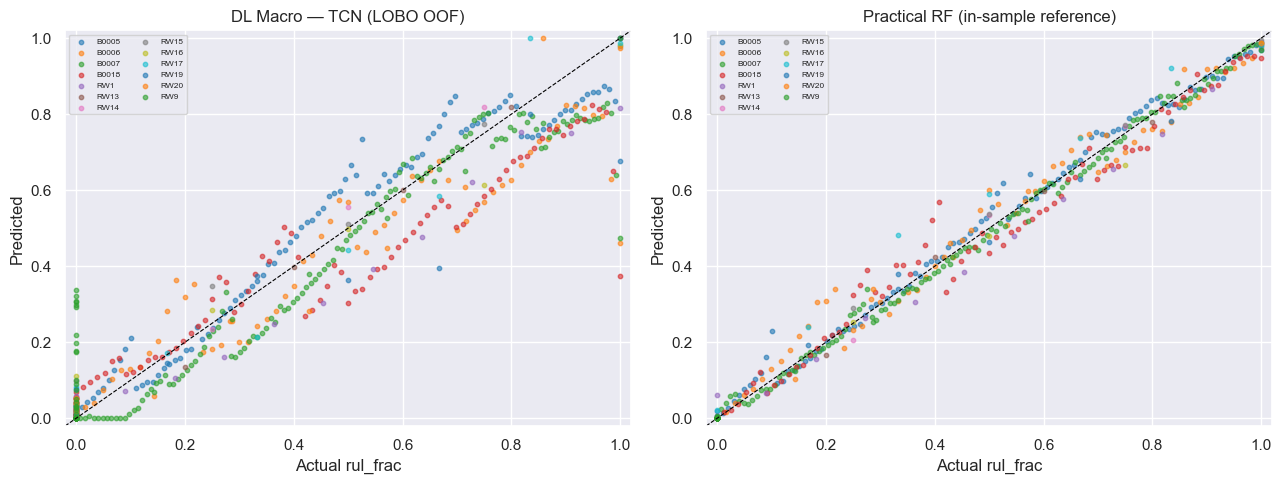

In [16]:
def oof_from_lobo(lobo_result):
    rows = []
    for fold in lobo_result["per_fold"]:
        bid = fold["battery"]
        for i in range(len(fold["y_true_arr"])):
            rows.append({
                "battery_id":  bid,
                "cycle_index": int(fold["cidx_arr"][i]),
                "y_true":      float(fold["y_true_arr"][i]),
                "y_pred":      float(fold["y_pred_arr"][i]),
            })
    return pd.DataFrame(rows)

oof_dl = oof_from_lobo(lobo_life_tcn)

# RF baseline: reload pkl and predict on merged (in-sample, for scale reference)
import joblib
rf_data = joblib.load(MODELS / "practical_lifespan_rf.pkl")
oof_rf  = pd.DataFrame({
    "battery_id":  merged["battery_id"].values,
    "cycle_index": merged["cycle_index"].values,
    "y_true":      merged["rul_frac"].values,
    "y_pred":      rf_data["model"].predict(merged[rf_data["feature_cols"]]),
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, oof, title in [
    (axes[0], oof_dl, f"DL Macro \u2014 TCN (LOBO OOF)"),
    (axes[1], oof_rf, "Practical RF (in-sample reference)"),
]:
    for bid, grp in oof.groupby("battery_id"):
        ax.scatter(grp["y_true"], grp["y_pred"], s=10, alpha=0.6, label=bid)
    ax.plot([-0.02, 1.02], [-0.02, 1.02], "k--", lw=0.8)
    ax.set(xlim=(-0.02, 1.02), ylim=(-0.02, 1.02),
           xlabel="Actual rul_frac", ylabel="Predicted", title=title)
    ax.legend(fontsize=6, ncol=2)
plt.tight_layout()
plt.savefig(RESULTS / "dl_macro_predicted_vs_actual.png", dpi=150)
plt.show()

### RUL trajectory — longest held-out battery

Longest battery: B0005


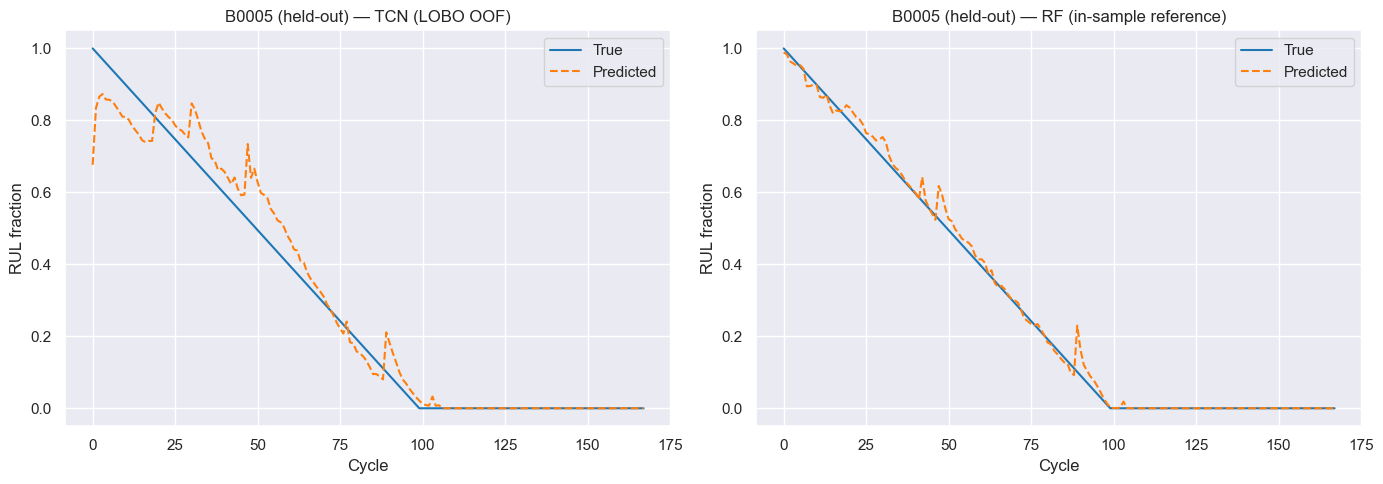

In [20]:
longest_bid = merged.groupby("battery_id")["cycle_index"].max().idxmax()
print(f"Longest battery: {longest_bid}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, oof, label in [
    (axes[0], oof_dl, "TCN (LOBO OOF)"),
    (axes[1], oof_rf, "RF (in-sample reference)"),
]:
    grp = oof[oof["battery_id"] == longest_bid].sort_values("cycle_index")
    ax.plot(grp["cycle_index"], grp["y_true"], label="True",      lw=1.5)
    ax.plot(grp["cycle_index"], grp["y_pred"], label="Predicted", lw=1.5, ls="--")
    ax.set(
        xlabel="Cycle", ylabel="RUL fraction",
        title=f"{longest_bid} (held-out) \u2014 {label}",
        ylim=(-0.05, 1.05),
    )
    ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "dl_macro_rul_trajectory.png", dpi=150)
plt.show()

## 9. Persist models

Retrain on all 13 batteries (no held-out) for a deployment checkpoint.
Checkpoint includes state_dict + scaler stats + metadata so it can be loaded without
re-running the notebook.

In [ ]:
scaler_all = StandardScaler().fit(merged[CHANNELS_LIFESPAN])
all_df = merged.copy()
all_df[CHANNELS_LIFESPAN] = scaler_all.transform(all_df[CHANNELS_LIFESPAN])
X_all, y_all, m_all, _, _ = make_sequences(all_df, CHANNELS_LIFESPAN, "rul_frac", L)

# Hold out a random 15 % as internal val for early stopping
rng     = np.random.default_rng(42)
n_val   = max(1, int(0.15 * len(X_all)))
val_idx = rng.choice(len(X_all), n_val, replace=False)
tr_idx  = np.setdiff1d(np.arange(len(X_all)), val_idx)

torch.manual_seed(42)
model = TCNReg(n_features=len(CHANNELS_LIFESPAN)).to(device)
train_model(
    model,
    X_all[tr_idx], m_all[tr_idx], y_all[tr_idx],
    X_all[val_idx], m_all[val_idx], y_all[val_idx],
    device, epochs=ep,
)

fname = MODELS / f"practical_lifespan_tcn_L{L}.pt"
torch.save({
    "state_dict":   {k: v.cpu() for k, v in model.state_dict().items()},
    "arch":         "TCN",
    "n_features":   len(CHANNELS_LIFESPAN),
    "channels":     CHANNELS_LIFESPAN,
    "lookback":     L,
    "phase":        "practical",
    "task":         "lifespan",
    "scaler_mean":  scaler_all.mean_.tolist(),
    "scaler_scale": scaler_all.scale_.tolist(),
}, fname)
print(f"Saved: {fname.name}")

## 10. Summary

### Results

**Tier-1 sweep** (fixed split, `rul_frac`) confirmed TCN as the strongest DL architecture
at L=5, converging in just 16 epochs (val MAE 0.031 vs LSTM 0.048, GRU 0.043).

**Tier-2 LOBO results vs Practical RF baseline:**

| | TCN (DL macro) | RF baseline |
|---|---|---|
| **Lifespan MAE** | 0.042 ± 0.021 | **0.032 ± 0.019** |
| **Lifespan R²** | 0.935 ± 0.078 | **0.966 ± 0.033** |
| **Lifespan MAE (cycles)** | 1.6 | **1.5** |
| **Lifespan monotonicity** | 0.847 | **0.926** |
| **Efficiency MAE** | 0.057 ± 0.032 | **0.032 ± 0.035** |
| **Efficiency R²** | 0.592 ± 0.570 | **0.848 ± 0.243** |

**Lifespan:** TCN loses to RF — MAE is 32% higher and monotonicity is lower (0.847 vs 0.926).
The cycle-level MAE is nearly identical (1.6 vs 1.5 cycles), but the RF trajectory is
smoother and more consistently monotone across folds.

**Efficiency:** TCN clearly loses — R² 0.592 with fold variance of ±0.570 means several
folds get near-zero or negative R². The efficiency signal is too noisy for a sequence model
operating on 13 trajectories.

### Why this happened, and why it matters

Both results follow directly from data starvation. With 13 trajectories, RF's bagging
provides better regularisation than a sequence model can achieve. The TCN converged in
just 16 epochs — a sign that it ran out of signal, not training time.

This is the intended finding. The baselines reduced each charge curve to a handful of
scalars and never saw the *shape* of that curve. Move to the within-cycle clock:
~800 charge-curve segments, each with 50–200 time-domain samples — and a signal the
scalar baselines literally cannot access.

### Narrative arc (for the deck)

1. **Baselines are strong** — RF MAE 0.032 / R² 0.966 sets the bar.
2. **Macro DL loses** (this notebook) — TCN MAE 0.042 / R² 0.935, monotonicity 0.847.
   Honest LOBO rematch; the loss is the finding, not a mistake.
3. **Reframe: change the clock.** 13 trajectories → data-starved. The charge curve
   shape is a signal the baselines never saw. Data count goes from 13 to ~800.
4. **Micro SOH estimation** (notebook 06) — DL earns its place.